In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import math

print("TensorFlow:", tf.__version__)

TensorFlow: 2.19.0


In [3]:
(x_train_full, y_train_full), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train_full = x_train_full.astype("float32") / 255.0
x_test       = x_test.astype("float32") / 255.0

mean = np.mean(x_train_full, axis=(0, 1, 2))
std  = np.std(x_train_full,  axis=(0, 1, 2))
x_train_full = (x_train_full - mean) / std
x_test       = (x_test - mean) / std

x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.1, random_state=42
)
print(f"Train: {x_train.shape}, Val: {x_val.shape}, Test: {x_test.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 10s 0us/step
Train: (45000, 32, 32, 3), Val: (5000, 32, 32, 3), Test: (10000, 32, 32, 3)


In [4]:
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
], name="augmentation")

In [5]:
def residual_block(x, filters, stride=1, name="res"):
    shortcut = x

    # First
    x = tf.keras.layers.BatchNormalization(name=f"{name}_bn1")(x)
    x = tf.keras.layers.Activation("relu", name=f"{name}_relu1")(x)
    x = tf.keras.layers.Conv2D(filters, 3, strides=stride, padding="same",
                               use_bias=False, name=f"{name}_conv1")(x)
    # Second
    x = tf.keras.layers.BatchNormalization(name=f"{name}_bn2")(x)
    x = tf.keras.layers.Activation("relu", name=f"{name}_relu2")(x)
    x = tf.keras.layers.Conv2D(filters, 3, padding="same",
                               use_bias=False, name=f"{name}_conv2")(x)

    if stride != 1 or shortcut.shape[-1] != filters:
        shortcut = tf.keras.layers.Conv2D(filters, 1, strides=stride,
                                          padding="same", use_bias=False,
                                          name=f"{name}_proj")(shortcut)

    return tf.keras.layers.Add(name=f"{name}_add")([x, shortcut])

In [6]:
def build_resnet_cifar(num_classes=10):
    inputs = tf.keras.Input(shape=(32, 32, 3), name="input")

    x = augment(inputs)
    x = tf.keras.layers.Conv2D(64, 3, padding="same", use_bias=False, name="stem_conv")(x)

    x = residual_block(x, 128, stride=2, name="s1_b1")
    x = residual_block(x, 128, stride=1, name="s1_b2")

    x = residual_block(x, 256, stride=2, name="s2_b1")
    x = residual_block(x, 256, stride=1, name="s2_b2")

    x = residual_block(x, 512, stride=2, name="s3_b1")
    x = residual_block(x, 512, stride=1, name="s3_b2")

    x = tf.keras.layers.BatchNormalization(name="final_bn")(x)
    x = tf.keras.layers.Activation("relu", name="final_relu")(x)


    x = tf.keras.layers.GlobalAveragePooling2D(name="gap")(x)
    x = tf.keras.layers.Dense(256, use_bias=False, name="fc1")(x)
    x = tf.keras.layers.BatchNormalization(name="fc_bn")(x)
    x = tf.keras.layers.Activation("relu", name="fc_relu")(x)
    x = tf.keras.layers.Dropout(0.4, name="dropout")(x)
    outputs = tf.keras.layers.Dense(num_classes, activation="softmax", name="output")(x)

    model = tf.keras.Model(inputs, outputs, name="resnet_cifar_v2")
    return model


model = build_resnet_cifar()
model.summary()


Model: "resnet_cifar_v2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 32, 32, 3) │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ augmentation        │ (None, 32, 32, 3) │          0 │ input[0][0]       │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 32, 32,    │      1,728 │ augmentation[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_bn1           │ (None, 32, 32,    │        256 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_relu1         │ (None, 32, 32,    │          0 │ s1_b1_bn1[0][0]   │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_conv1         │ (None, 16, 16,    │     73,728 │ s1_b1_relu1[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_bn2           │ (None, 16, 16,    │        512 │ s1_b1_conv1[0][0] │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_relu2         │ (None, 16, 16,    │          0 │ s1_b1_bn2[0][0]   │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_conv2         │ (None, 16, 16,    │    147,456 │ s1_b1_relu2[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_proj (Conv2D) │ (None, 16, 16,    │      8,192 │ stem_conv[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b1_add (Add)     │ (None, 16, 16,    │          0 │ s1_b1_conv2[0][0… │
│                     │ 128)              │            │ s1_b1_proj[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b2_bn1           │ (None, 16, 16,    │        512 │ s1_b1_add[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b2_relu1         │ (None, 16, 16,    │          0 │ s1_b2_bn1[0][0]   │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b2_conv1         │ (None, 16, 16,    │    147,456 │ s1_b2_relu1[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b2_bn2           │ (None, 16, 16,    │        512 │ s1_b2_conv1[0][0] │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b2_relu2         │ (None, 16, 16,    │          0 │ s1_b2_bn2[0][0]   │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ s1_b2_conv2         │ (None, 16, 16,    │    147,456 │ s1_b2_relu2[0][0] │
│ (Conv2D)            │ 128)              │            │                 

 Total params: 11,161,034 (42.58 MB)

 Trainable params: 11,153,226 (42.55 MB)

 Non-trainable params: 7,808 (30.50 KB)

In [7]:
EPOCHS     = 100
BATCH_SIZE = 128
STEPS_PER_EPOCH = math.ceil(len(x_train) / BATCH_SIZE)
WARMUP_EPOCHS   = 5

total_steps  = EPOCHS * STEPS_PER_EPOCH
warmup_steps = WARMUP_EPOCHS * STEPS_PER_EPOCH

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=0.1,
    decay_steps=total_steps - warmup_steps,
    alpha=1e-6
)

class WarmupCosineDecay(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, warmup_steps, schedule):
        self.warmup_steps = warmup_steps
        self.schedule = schedule

    def __call__(self, step):
        warmup_lr = 0.1 * tf.cast(step, tf.float32) / tf.cast(self.warmup_steps, tf.float32)
        cosine_lr = self.schedule(tf.maximum(step - self.warmup_steps, 0))
        return tf.cond(step < self.warmup_steps, lambda: warmup_lr, lambda: cosine_lr)

    def get_config(self):
        return {}

lr = WarmupCosineDecay(warmup_steps, lr_schedule)

optimizer = tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9, nesterov=True)

In [8]:

NUM_CLASSES = 10
y_train_oh = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_val_oh   = tf.keras.utils.to_categorical(y_val,   NUM_CLASSES)
y_test_oh  = tf.keras.utils.to_categorical(y_test,  NUM_CLASSES)

model.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=["accuracy"]
)

In [9]:
callbacks = [
    # Save best weights
    tf.keras.callbacks.ModelCheckpoint(
        "best_resnet_cifar.keras",
        monitor="val_accuracy",
        save_best_only=True,
        verbose=1
    ),
    # Early stopping
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=20,
        restore_best_weights=True,
        verbose=1
    ),
]

### 9. Train


In [10]:
history = model.fit(
    x_train, y_train_oh,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(x_val, y_val_oh),
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.2672 - loss: 2.2035
Epoch 1: val_accuracy improved from None to 0.42520, saving model to best_resnet_cifar.keras

Epoch 1: finished saving model to best_resnet_cifar.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - accuracy: 0.3471 - loss: 1.9557 - val_accuracy: 0.4252 - val_loss: 1.7415
Epoch 2/100
351/352 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4661 - loss: 1.6654
Epoch 2: val_accuracy improved from 0.42520 to 0.45920, saving model to best_resnet_cifar.keras

Epoch 2: finished saving model to best_resnet_cifar.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.4898 - loss: 1.6171 - val_accuracy: 0.4592 - val_loss: 1.8011
Epoch 3/100
352/352 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5457 - loss: 1.5105
Epoch 3: val_accuracy improved from 0.45920 to 0.56820, saving model to best_resnet_cifar.keras

Epoch 3: finished saving model to best_resnet_cifar.keras
352/352 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/

### 10. Evaluate


In [11]:
test_loss, test_acc = model.evaluate(x_test, y_test_oh, verbose=2)
print(f"\nTest Accuracy (ResNet CNN v2): {test_acc*100:.2f}%")
print(f"Baseline v1 accuracy:          74.03%")
print(f"Improvement:                   +{(test_acc - 0.7403)*100:.2f}%")

313/313 - 2s - 6ms/step - accuracy: 0.9067 - loss: 0.7380

Test Accuracy (ResNet CNN v2): 90.67%
Baseline v1 accuracy:          74.03%
Improvement:                   +16.64%


### 11. Training curves


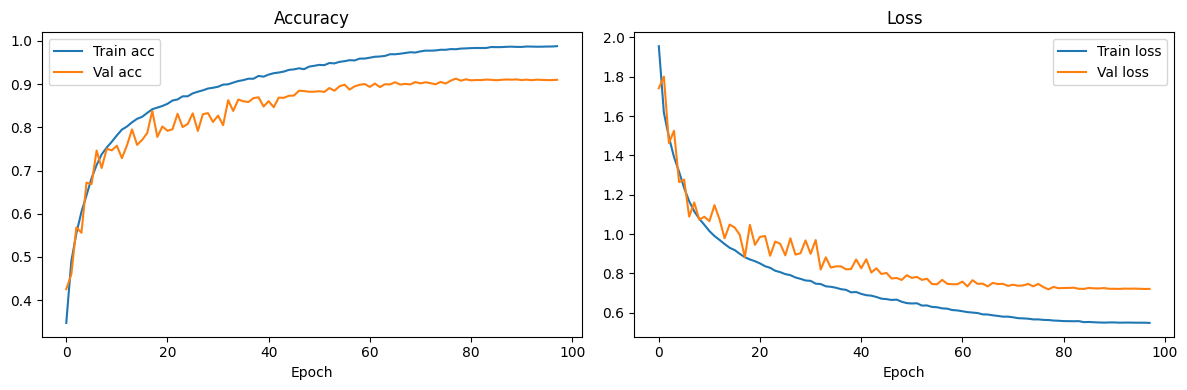

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history["accuracy"],     label="Train acc")
ax1.plot(history.history["val_accuracy"], label="Val acc")
ax1.set_title("Accuracy"); ax1.legend(); ax1.set_xlabel("Epoch")

ax2.plot(history.history["loss"],     label="Train loss")
ax2.plot(history.history["val_loss"], label="Val loss")
ax2.set_title("Loss"); ax2.legend(); ax2.set_xlabel("Epoch")

plt.tight_layout()
plt.savefig("training_curves_v2.png", dpi=150)
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


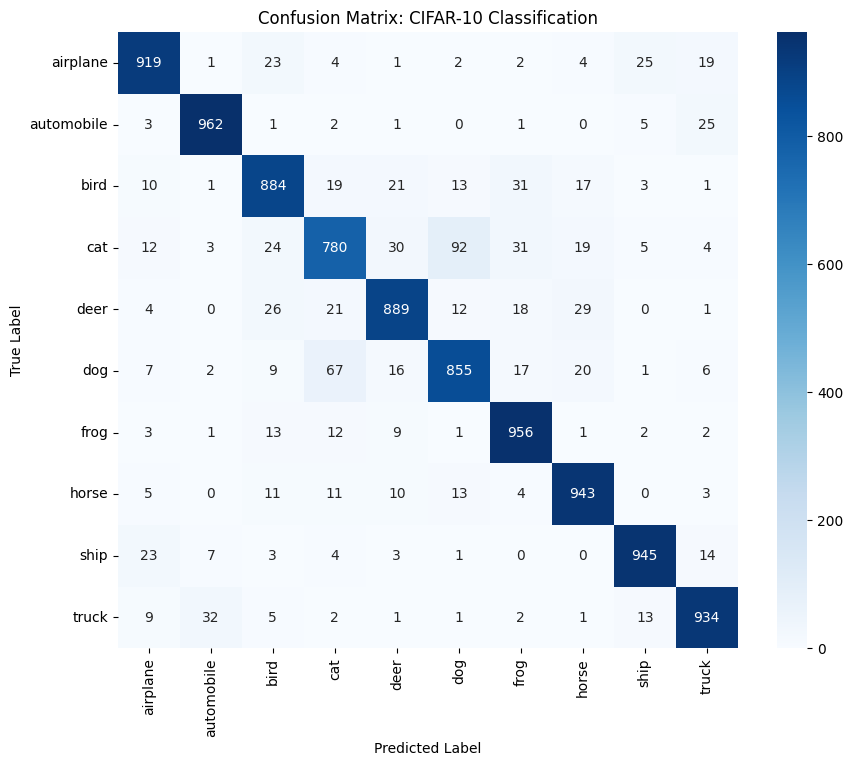

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)

if len(y_test.shape) > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test.flatten()

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: CIFAR-10 Classification')
plt.show()